# Imports

In [1]:
from pathlib import Path
import math
import os
import sys
from random import random

import torch
from torchvision.datasets import VisionDataset, MNIST, EMNIST
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision.transforms import GaussianBlur

from utils.checkpoint import load_checkpoint
from utils.data import get_dataloaders, get_datasets

PROJECT_ROOT = Path(os.path.abspath(os.pardir))
sys.path.append(str(PROJECT_ROOT))

from models.lenet import Net as LeNet
from config import Config, load_config

In [3]:
from config import get_dataset

mnist_config = load_config(str(PROJECT_ROOT / "configs" / "mnist" / "lenet_baseline.yaml"))
emnist_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters" / "lenet_baseline.yaml"))
emnist10_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters-10" / "lenet.yaml"))
emnist18_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters-18" / "lenet.yaml"))


In [11]:
from torch.utils.data import DataLoader
from typing import Callable

def make_loader(
    dataset_cls: Callable[..., VisionDataset],
    *,
    dataset_kwargs: dict | None=None,
    dataset_transforms: Callable[..., VisionDataset] | None=None,
    batch_size: int = 128,
):
    dataset_kwargs = dataset_kwargs or {}

    _, test_dataset = get_datasets(
        root=str(PROJECT_ROOT / "data"),
        dataset=dataset_cls,
        download=True,
        normalize=True,
        dataset_kwargs=dataset_kwargs
    )

    test_dataset = dataset_transforms(test_dataset) if dataset_transforms else test_dataset

    return DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=1,
    )

# Preliminary functions

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 42
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [19]:
def to_tensors(evals: dict) -> dict:
    return {ks: tuple(torch.from_numpy(array) for array in values) for ks, values in evals.items()}
_d = np.load(f"npz/mnist_vs_emnist-letters_comparison_seed_42.npz", allow_pickle=True)
T: int = int(_d["mc_samples"])
kernel_sizes: list[int] = _d["kernel_sizes"].tolist()
mnist_evals = to_tensors(_d["mnist_evals"].item())
emnist_evals = to_tensors(_d["emnist_evals"].item())
emnist10_evals = to_tensors(_d["emnist-10_evals"].item())
emnist18_evals = to_tensors(_d["emnist-18_evals"].item())
del _d



In [13]:
from config import build_transform

mnist_labels = torch.cat([y for _, y in make_loader(MNIST)]).cpu()
emnist_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                     dataset_kwargs=emnist_config.data.kwargs)]).cpu()
emnist10_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                       dataset_kwargs=emnist10_config.data.kwargs,
                                                       dataset_transforms=build_transform(emnist10_config.data.dataset_transform))]).cpu()
emnist18_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                       dataset_kwargs=emnist18_config.data.kwargs,
                                                       dataset_transforms=build_transform(emnist18_config.data.dataset_transform))]).cpu()


# Метрики



## Вычисление точности


In [14]:
def calculate_accuracy(preds: torch.Tensor, labels: torch.Tensor) -> float:
    correct = (preds.argmax(dim=1) == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [20]:
mnist_accuracies = [calculate_accuracy(mnist_evals[ks][0], mnist_labels) for ks in kernel_sizes]
emnist_accuracies = [calculate_accuracy(emnist_evals[ks][0], emnist_labels) for ks in kernel_sizes]
emnist10_accuracies = [calculate_accuracy(emnist10_evals[ks][0], emnist10_labels) for ks in kernel_sizes]
emnist18_accuracies = [calculate_accuracy(emnist18_evals[ks][0], emnist18_labels) for ks in kernel_sizes]

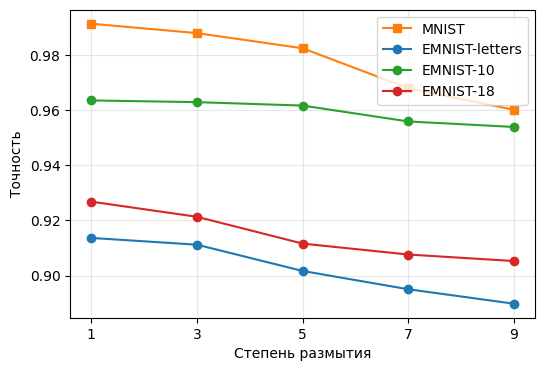

In [51]:
fig, ax = plt.subplots(figsize=(6, 4))

markers = {'E': 'o', 'M': 's'}
colors = {'E': 'C0', 'M': 'C1', 'E10': 'C2', 'E18': 'C3'}

ax.plot(kernel_sizes, mnist_accuracies, color=colors['M'], label="MNIST", marker=markers['M'])
ax.plot(kernel_sizes, emnist_accuracies, color=colors['E'], label="EMNIST-letters", marker=markers['E'])
ax.plot(kernel_sizes, emnist10_accuracies, color=colors['E10'], label="EMNIST-10", marker=markers['E'])
ax.plot(kernel_sizes, emnist18_accuracies, color=colors['E18'], label="EMNIST-18", marker=markers['E'])

ax.set_xticks(kernel_sizes)
ax.set_xlabel("Степень размытия")
ax.set_ylabel("Точность")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

## Вычисление неопределенности

In [43]:
mnist_total_unc = [mnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
mnist_alea_unc = [mnist_evals[ks][2].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
mnist_epis_unc = [mnist_evals[ks][3].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]

emnist_total_unc = [emnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
emnist_alea_unc = [emnist_evals[ks][2].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
emnist_epis_unc = [emnist_evals[ks][3].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]

emnist10_total_unc = [emnist10_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
emnist10_alea_unc = [emnist10_evals[ks][2].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
emnist10_epis_unc = [emnist10_evals[ks][3].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]

emnist18_total_unc = [emnist18_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
emnist18_alea_unc = [emnist18_evals[ks][2].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
emnist18_epis_unc = [emnist18_evals[ks][3].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]


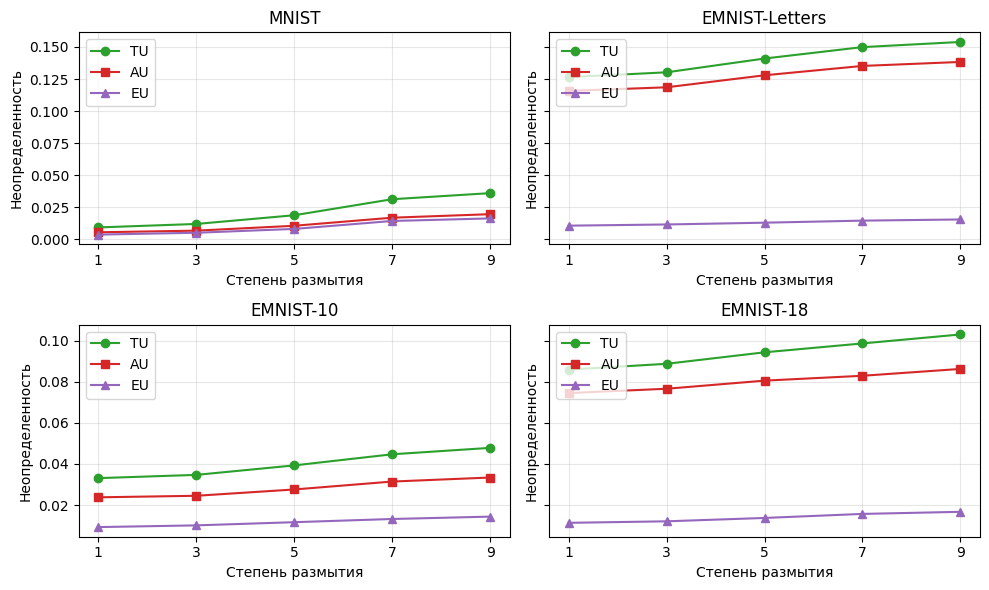

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey='row')

markers = {'TU': 'o', 'AU': 's', 'EU': '^'}
colors = {'TU': 'C2', 'AU': 'C3', 'EU': 'C4'}

datasets = [
    ("MNIST", mnist_total_unc, mnist_alea_unc, mnist_epis_unc),
    ("EMNIST-Letters", emnist_total_unc, emnist_alea_unc, emnist_epis_unc),
    ("EMNIST-10", emnist10_total_unc, emnist10_alea_unc, emnist10_epis_unc),
    ("EMNIST-18", emnist18_total_unc, emnist18_alea_unc, emnist18_epis_unc),
]

for ax, (name, total, alea, epis) in zip(axes.flat, datasets):
    ax.plot(kernel_sizes, total, label='TU', marker=markers['TU'], color=colors['TU'])
    ax.plot(kernel_sizes, alea, label='AU', marker=markers['AU'], color=colors['AU'])
    ax.plot(kernel_sizes, epis, label='EU', marker=markers['EU'], color=colors['EU'])
    ax.set_title(name)
    ax.set_xlabel("Степень размытия")
    ax.set_ylabel('Неопределенность')
    ax.set_xticks(kernel_sizes)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

plt.tight_layout()


## Калибровка моделей

In [16]:
from utils.calibration import expected_calibration_error

mnist_preds = mnist_evals[1][0]
mnist_ece, mnist_bin_conf, mnist_bin_acc = expected_calibration_error(mnist_preds, mnist_labels, 20, 10)

emnist_preds = emnist_evals[1][0]
emnist_ece, emnist_bin_conf, emnist_bin_acc = expected_calibration_error(emnist_preds, emnist_labels, 20, 26)

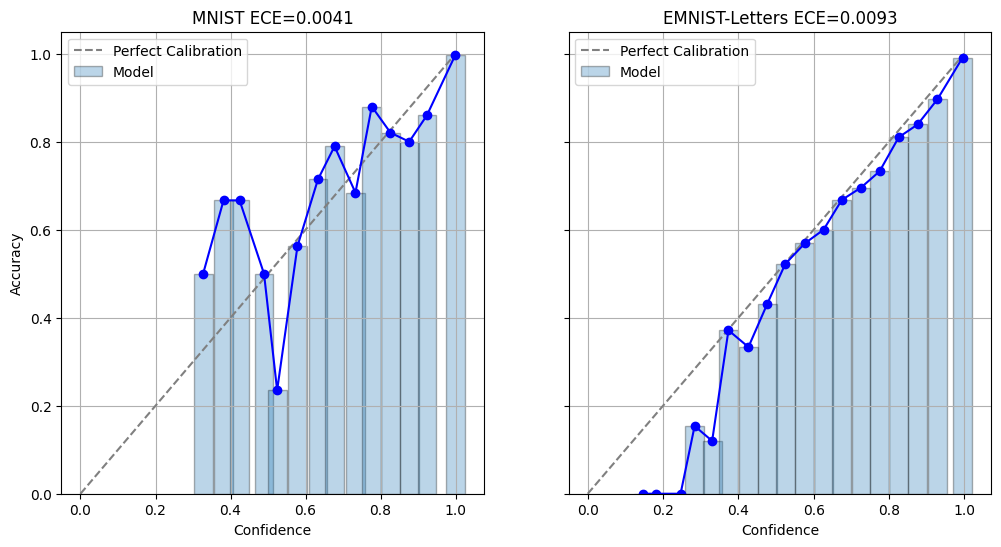

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration")
axes[0].bar(mnist_bin_conf, mnist_bin_acc, width=0.05, alpha=0.3, edgecolor="black", label="Model")
axes[0].plot(mnist_bin_conf, mnist_bin_acc, marker="o", color="blue")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Accuracy")
axes[0].set_title(f"MNIST ECE={mnist_ece:.4f}")
axes[0].legend(loc='upper left')
axes[0].grid(True)

axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration")
axes[1].bar(emnist_bin_conf, emnist_bin_acc, width=0.05, alpha=0.3, edgecolor="black", label="Model")
axes[1].plot(emnist_bin_conf, emnist_bin_acc, marker="o", color="blue")
axes[1].set_xlabel("Confidence")
axes[1].set_title(f"EMNIST-Letters ECE={emnist_ece:.4f}")
axes[1].legend(loc='upper left')
axes[1].grid(True)


# Корреляция между предсказанной уверенностью и неопределенностью

In [59]:
import numpy as np

def calculate_correlations(probs: torch.Tensor, total_uncs: torch.Tensor, labels: torch.Tensor) -> tuple[float, float]:
    """
    Calculate Pearson correlations between predicted and true confidences and total uncertainties.
    Args:
        probs: Tensor of shape [B, C] with predicted probabilities for each class
        total_uncs: Tensor of shape [B] with total uncertainties
        labels: Tensor of shape [B] with true labels

    Returns:
        tuple[float, float]: Pearson correlations for predicted and true confidences

    """
    pred_conf = probs[torch.arange(len(probs)), probs.argmax(dim=1)].cpu().numpy() # [B]
    true_conf = probs[torch.arange(len(labels)), labels].cpu().numpy() # [B]
    total_uncs = total_uncs.cpu().numpy() # [B]
    return np.corrcoef(pred_conf, total_uncs)[0, 1], np.corrcoef(true_conf, total_uncs)[0, 1]

mnist_correlations_pred = [calculate_correlations(mnist_evals[ks][0], mnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), mnist_labels)[0] for ks in kernel_sizes]
mnist_correlations_true = [calculate_correlations(mnist_evals[ks][0], mnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), mnist_labels)[1] for ks in kernel_sizes]

emnist_correlations_pred = [calculate_correlations(emnist_evals[ks][0], emnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), emnist_labels)[0] for ks in kernel_sizes]
emnist_correlations_true = [calculate_correlations(emnist_evals[ks][0], emnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), emnist_labels)[1] for ks in kernel_sizes]

emnist10_correlations_pred = [calculate_correlations(emnist10_evals[ks][0], emnist10_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), emnist10_labels)[0] for ks in kernel_sizes]
emnist10_correlations_true = [calculate_correlations(emnist10_evals[ks][0], emnist10_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), emnist10_labels)[1] for ks in kernel_sizes]

emnist18_correlations_pred = [calculate_correlations(emnist18_evals[ks][0], emnist18_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), emnist18_labels)[0] for ks in kernel_sizes]
emnist18_correlations_true = [calculate_correlations(emnist18_evals[ks][0], emnist18_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1), emnist18_labels)[1] for ks in kernel_sizes]



In [69]:
print(mnist_correlations_true)

[np.float64(-0.7032595873768689), np.float64(-0.7260334011389276), np.float64(-0.7428271794467998), np.float64(-0.7351240145796174), np.float64(-0.7001670057008104)]


# Левый subplot — pred_conf

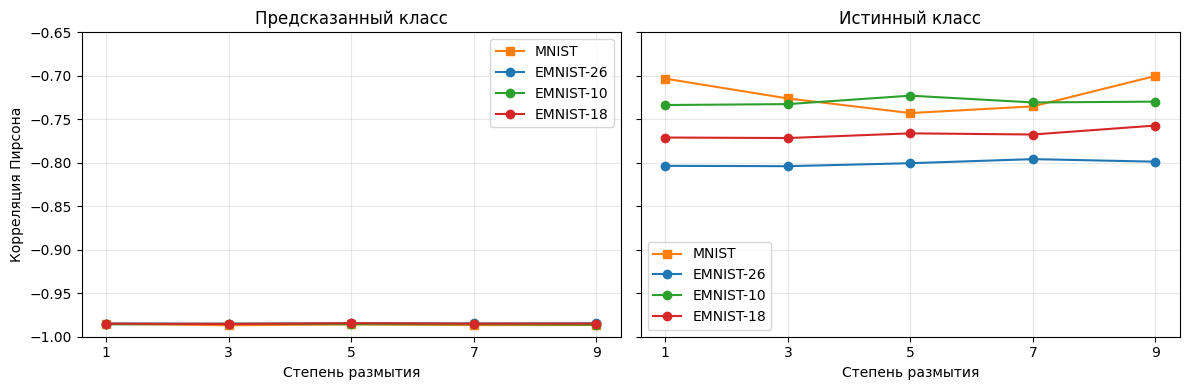

In [70]:
colors = {'MNIST': 'C1', 'EMNIST-10': 'C2', 'EMNIST-18': 'C3', 'EMNIST-26': 'C0'}
markers = {'MNIST': 's', 'EMNIST-10': 'o', 'EMNIST-18': 'o', 'EMNIST-26': 'o'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(kernel_sizes, mnist_correlations_pred, marker=markers['MNIST'], color=colors['MNIST'], label='MNIST')
axes[0].plot(kernel_sizes, emnist_correlations_pred, marker=markers['EMNIST-26'], color=colors['EMNIST-26'], label='EMNIST-26')
axes[0].plot(kernel_sizes, emnist10_correlations_pred, marker=markers['EMNIST-10'], color=colors['EMNIST-10'], label='EMNIST-10')
axes[0].plot(kernel_sizes, emnist18_correlations_pred, marker=markers['EMNIST-18'], color=colors['EMNIST-18'], label='EMNIST-18')
axes[0].set_title("Предсказанный класс")
axes[0].set_ylabel("Корреляция Пирсона")

axes[1].plot(kernel_sizes, mnist_correlations_true, marker=markers['MNIST'], color=colors['MNIST'], label='MNIST')
axes[1].plot(kernel_sizes, emnist_correlations_true, marker=markers['EMNIST-26'], color=colors['EMNIST-26'], label='EMNIST-26')
axes[1].plot(kernel_sizes, emnist10_correlations_true, marker=markers['EMNIST-10'], color=colors['EMNIST-10'], label='EMNIST-10')
axes[1].plot(kernel_sizes, emnist18_correlations_true, marker=markers['EMNIST-18'], color=colors['EMNIST-18'], label='EMNIST-18')
axes[1].set_title("Истинный класс")

for i in range(2):
    axes[i].set_xticks(kernel_sizes)
    axes[i].set_xlabel("Степень размытия")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(bottom=-1, top=-0.65)
    axes[i].legend()

plt.tight_layout()
plt.show()



# Правый subplot — true_conf


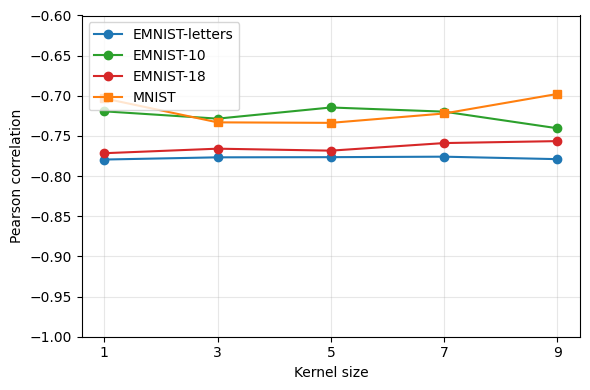

In [38]:
fig, ax = plt.subplots(figsize=(6, 4), sharey=True)

ax.plot(kernel_sizes, emnist_correlations_true, marker=markers['EMNIST-26'], color=colors['EMNIST-26'], label='EMNIST-26')
ax.plot(kernel_sizes, mnist_correlations_true, marker=markers['MNIST'], color=colors['MNIST'], label='MNIST')
# ax.set_title('True class')
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Степень размытия")
ax.set_ylabel("Корреляция Пирсона")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-1,top=-0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()



# Log-score uncertainty

In [115]:
from tqdm import tqdm
from torch.utils.data import DataLoader
from typing import Callable, Any

from utils.uncertainty import mc_predict, quantify_uncertainties

def evaluate_with_blurs(
    model: torch.nn.Module,
    dataset_cls: Callable[..., VisionDataset],
    dataset_kwargs: dict | None,
    dataset_transforms: Callable[..., VisionDataset] | None,
    kernel_sizes: list[int],
    device: torch.device,
    mc_samples: int = 10,
    desc: str = "",
) -> dict[int, tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]]:
    """
    Returns dict with keys as kernel sizes and values as tuples of:
    (predictions, total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty)
    """
    res = {}

    pbar = tqdm(kernel_sizes, desc=desc)

    for ks in pbar:
        pbar.set_description(f"{desc} - Kernel {ks}")
        k_blur_preds, k_blur_tus, k_blur_aus, k_blur_eus = [], [], [], []

        loader = make_loader(
            dataset_cls,
            dataset_kwargs=dataset_kwargs,
            dataset_transforms=dataset_transforms,
            kernel_size=ks,
        )

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            mc_preds = mc_predict(model, x, mc_samples=mc_samples)
            log_mc_p = mc_preds.clamp_min(1e-8).log()
            au = -(mc_preds * log_mc_p).sum(dim=-1).mean(dim=0) # [B]
            eu = -(mc_preds * mc_preds.mean(dim=0).clamp_min(1e-8).log()).sum(dim=-1).mean(dim=0) - au
            k_blur_preds.append(mc_preds.mean(dim=0))
            k_blur_tus.append(au+eu)
            k_blur_aus.append(au)
            k_blur_eus.append(eu)

        k_blur_preds = torch.cat(k_blur_preds, dim=0)
        k_blur_tus = torch.cat(k_blur_tus, dim=0)
        k_blur_aus = torch.cat(k_blur_aus, dim=0)
        k_blur_eus = torch.cat(k_blur_eus, dim=0)

        res[ks] = (k_blur_preds, k_blur_tus, k_blur_aus, k_blur_eus)

    return res

In [116]:
from torchvision.datasets import MNIST

mnist_evals = evaluate_with_blurs(
    mnist_model,
    MNIST,
    None,
    None,
    kernel_sizes, device, T,
    desc="MNIST Gaussian Blur",
)

MNIST Gaussian Blur - Kernel 9: 100%|██████████| 5/5 [05:29<00:00, 65.87s/it]


In [126]:
emnist_evals = evaluate_with_blurs(
    emnist_model,
    EMNIST,
    {"split": "letters"},
    None,
    kernel_sizes, device, T,
    desc="EMNIST Gaussian Blur",
)

EMNIST Gaussian Blur - Kernel 9: 100%|██████████| 5/5 [12:30<00:00, 150.02s/it]


In [128]:
np.savez(
    "npz/mnist_vs_emnist-letters_comparison_log_score.npz",
    kernel_sizes=kernel_sizes,
    mc_samples=T,
    mnist_evals=mnist_evals,
    emnist_evals=emnist_evals
)

In [120]:
import random
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# eu = torch.nn.functional.kl_div(log_mc_p, mc_preds.mean(dim=0, keepdim=True), reduction='batchmean')

loader = make_loader(
    MNIST,
    kernel_size=1,
)

for x, y in loader:
    x, y = x.to(device), y.to(device)
    mc_preds = mc_predict(mnist_model, x, mc_samples=T)
    log_mc_p = mc_preds.clamp_min(1e-8).log()
    au = -(mc_preds * log_mc_p).sum(dim=-1).mean(dim=0) # [B]
    eu = -(mc_preds * mc_preds.mean(dim=0).clamp_min(1e-8).log()).sum(dim=-1).mean(dim=0) - au
    print(au)
    print(eu)
    print(au + eu)
    break
    # eu = torch.nn.functional.kl_div(log_mc_p, mc_preds.mean(dim=0, keepdim=True), reduction='batchmean')


tensor([3.1222e-06, 6.2960e-06, 1.1911e-06, 1.1769e-05, 5.3645e-06, 2.2171e-06,
        2.1389e-03, 3.6722e-06, 1.9420e-01, 3.9248e-06, 1.9044e-06, 5.5827e-06,
        1.2377e-06, 4.7899e-07], device='cuda:0')
tensor([ 3.0574e-08,  2.5308e-07, -7.8431e-09,  7.6215e-07,  1.7770e-07,
         5.4055e-08,  1.4154e-04,  2.0853e-07,  2.8782e-01,  1.1566e-07,
         3.5376e-08,  1.3492e-07,  4.9453e-09, -1.2200e-09], device='cuda:0')
tensor([3.1528e-06, 6.5491e-06, 1.1832e-06, 1.2531e-05, 5.5422e-06, 2.2711e-06,
        2.2804e-03, 3.8807e-06, 4.8202e-01, 4.0405e-06, 1.9398e-06, 5.7177e-06,
        1.2426e-06, 4.7777e-07], device='cuda:0')


In [132]:
mnist_correlations_total_true = [calculate_correlations(mnist_evals[ks][0], mnist_evals[ks][1], mnist_labels)[1] for ks in kernel_sizes]
emnist_correlations_total_true = [calculate_correlations(emnist_evals[ks][0], emnist_evals[ks][1], emnist_labels)[1] for ks in kernel_sizes]

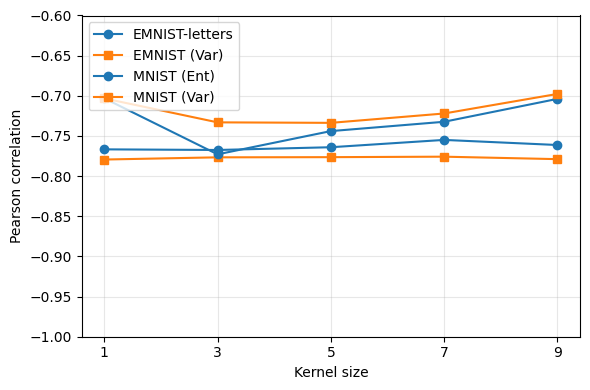

In [133]:
fig, ax = plt.subplots(figsize=(6, 4), sharey=True)

colors = {'E': 'C0', 'M': 'C1'}
markers = {'E': 'o', 'M': 's'}

ax.plot(kernel_sizes, emnist_correlations_total_true, marker=markers['E'], color=colors['E'], label='EMNIST-letters')
ax.plot(kernel_sizes, emnist_correlations_true, marker=markers['M'], color=colors['M'], label='EMNIST (Var)')
ax.plot(kernel_sizes, mnist_correlations_total_true, marker=markers['E'], color=colors['E'], label='MNIST (Ent)')
ax.plot(kernel_sizes, mnist_correlations_true, marker=markers['M'], color=colors['M'], label='MNIST (Var)')
# ax.set_title('True class')
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Pearson correlation")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-1,top=-0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()



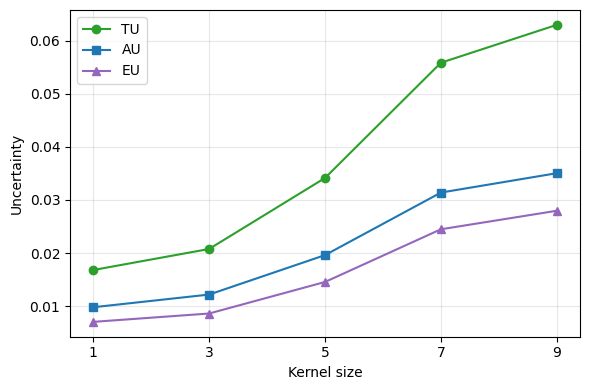

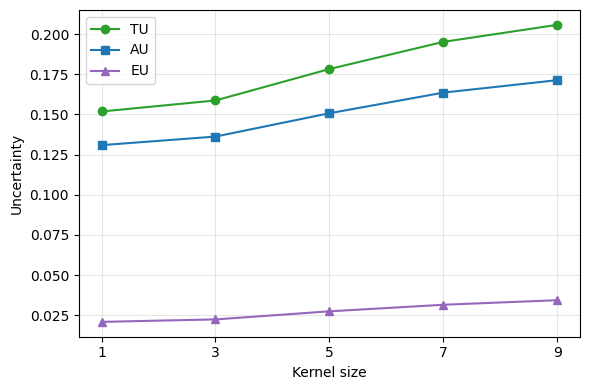

In [130]:
mnist_total_unc = [mnist_evals[ks][1].mean().item() for ks in kernel_sizes]
mnist_alea_unc = [mnist_evals[ks][2].mean().item() for ks in kernel_sizes]
mnist_epis_unc = [mnist_evals[ks][3].mean().item() for ks in kernel_sizes]

emnist_total_unc = [emnist_evals[ks][1].mean().item() for ks in kernel_sizes]
emnist_alea_unc = [emnist_evals[ks][2].mean().item() for ks in kernel_sizes]
emnist_epis_unc = [emnist_evals[ks][3].mean().item() for ks in kernel_sizes]

colors = {'TU': 'C2', 'AU': 'C3', 'EU': 'C4'}

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kernel_sizes, mnist_total_unc, label='TU', marker='o', color=colors['TU'])
ax.plot(kernel_sizes, mnist_alea_unc,  label='AU', marker='s')
ax.plot(kernel_sizes, mnist_epis_unc,  label='EU', marker='^', color=colors['EU'])
# ax.set_title('EMNIST-letters')
ax.set_xlabel('Kernel size')
ax.set_ylabel('Uncertainty')
ax.set_xticks(kernel_sizes)
ax.grid(True, alpha=0.3)
# ax.set_ylim(top=0.07)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kernel_sizes, emnist_total_unc, label='TU', marker='o', color=colors['TU'])
ax.plot(kernel_sizes, emnist_alea_unc,  label='AU', marker='s')
ax.plot(kernel_sizes, emnist_epis_unc,  label='EU', marker='^', color=colors['EU'])
# ax.set_title('EMNIST-letters')
ax.set_xlabel('Kernel size')
ax.set_ylabel('Uncertainty')
ax.set_xticks(kernel_sizes)
ax.grid(True, alpha=0.3)
# ax.set_ylim(top=0.07)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()
